# 1 · Vektorräume, Normen und Distanzmetriken

**Reihe:** Mathematische Grundlagen des Maschinellen Lernens · Notebook 1 von 5
**Voraussetzungen:** Lineare Algebra I, Analysis I
**Bearbeitungszeit:** ca. 60 Minuten

---

### Zusammenfassung

Nahezu jedes Lernverfahren misst Ähnlichkeit — $k$-nächste Nachbarn, $k$-Means, kernbasierte
Methoden und die Retrieval-Komponente moderner Sprachmodelle unterscheiden sich vor allem darin,
*welche* Distanz sie verwenden. Dieses Notebook entwickelt den dafür nötigen Begriffsapparat:
normierte Vektorräume, die von einer Norm induzierte Metrik und die Winkelgeometrie des
Standardskalarprodukts. Wir belegen anschließend zwei Punkte, die in der Praxis regelmäßig
übersehen werden: die häufig verwendete Kosinus-*Distanz* ist keine Metrik, und in hohen
Dimensionen verliert der Kontrast zwischen nächstem und fernstem Nachbarn systematisch an
Aussagekraft. Alle Sätze werden bewiesen und anschließend numerisch überprüft.

### Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. die Normaxiome nachrechnen und begründen, warum $\|\cdot\|_p$ für $p < 1$ keine Norm ist;
2. den Zusammenhang zwischen Norm, induzierter Metrik und Skalarprodukt darstellen;
3. die Cauchy–Schwarz-Ungleichung beweisen und daraus die Wohldefiniertheit des Winkels folgern;
4. die Metrikaxiome für eine gegebene Distanzfunktion numerisch falsifizieren;
5. den Effekt der Distanzkonzentration quantifizieren und seine Konsequenz für $k$-NN benennen;
6. begründen, warum Merkmalsskalierung Teil jedes distanzbasierten Verfahrens sein muss.

### Inhalt

1. [Normierte Vektorräume](#1)
2. [Metriken und die induzierte Distanz](#2)
3. [Skalarprodukt, Cauchy–Schwarz und Winkel](#3)
4. [Die Kosinus-Distanz ist keine Metrik](#4)
5. [Distanzkonzentration in hohen Dimensionen](#5)
6. [Merkmalsskalierung](#6)
7. [Übungsaufgaben](#7)

## 0 Vorbereitung

Die folgende Zelle lädt die Abhängigkeiten, fixiert den Zufallsgenerator und setzt
das einheitliche Abbildungslayout der Reihe. Sie ist in allen Notebooks identisch
und muss vor allen weiteren Zellen ausgeführt werden.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

# Reproduzierbarkeit: fester Seed für alle stochastischen Experimente dieses Notebooks
SEED = 20260730
rng = np.random.default_rng(SEED)

# Einheitliches Abbildungslayout für die gesamte Notebook-Reihe.
# Die Farbfolge ist auf Farbfehlsichtigkeit geprüft (Blau, Orange, Aquamarin,
# Violett, Rot); benachbarte Serien sind sowohl in der Helligkeit als auch im
# Farbton unterscheidbar.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#e34948"]

mpl.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.prop_cycle": cycler(color=PALETTE),
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.labelcolor": "#0b0b0b",
    "grid.color": "#d8d7d2",
    "grid.linewidth": 0.6,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
    "font.size": 10,
    "mathtext.fontset": "cm",
})

np.set_printoptions(precision=4, suppress=True)
print(f"NumPy {np.__version__} · Matplotlib {mpl.__version__} · Seed {SEED}")

NumPy 2.4.6 · Matplotlib 3.11.1 · Seed 20260730


<a id="1"></a>
## 1 Normierte Vektorräume

> **Definition 1.1 (Norm).** Sei $V$ ein reeller Vektorraum. Eine Abbildung
> $\|\cdot\| : V \to \mathbb{R}_{\ge 0}$ heißt *Norm*, wenn für alle $x, y \in V$ und
> $\lambda \in \mathbb{R}$ gilt:
>
> | | Axiom | Bedeutung |
> |---|---|---|
> | (N1) | $\|x\| = 0 \iff x = 0$ | Definitheit |
> | (N2) | $\|\lambda x\| = \lvert\lambda\rvert\,\|x\|$ | absolute Homogenität |
> | (N3) | $\|x + y\| \le \|x\| + \|y\|$ | Dreiecksungleichung |
>
> Das Paar $(V, \|\cdot\|)$ heißt *normierter Vektorraum*.

> **Beispiel 1.2 ($p$-Norm).** Für $x \in \mathbb{R}^n$ und $p \ge 1$ ist
> $$\|x\|_p \;=\; \Big(\sum_{i=1}^{n} \lvert x_i \rvert^{\,p}\Big)^{1/p}, \qquad
> \|x\|_\infty \;=\; \max_{1 \le i \le n} \lvert x_i \rvert$$
> eine Norm. Die Fälle $p = 1$ (Manhattan-, Taxi- oder City-Block-Norm), $p = 2$ (euklidische
> Norm) und $p = \infty$ (Maximums- oder Tschebyschow-Norm) sind die im Maschinellen Lernen
> gebräuchlichen. Die Dreiecksungleichung für $1 \le p < \infty$ ist die Minkowski-Ungleichung;
> ihr Beweis findet sich in jedem Analysis-Lehrbuch (z. B. Königsberger 2004, Kap. 1).

> **Satz 1.3.** Für $0 < p < 1$ ist $\|\cdot\|_p$ auf $\mathbb{R}^n$, $n \ge 2$, **keine** Norm.
>
> *Beweis.* Sei $x = (1,0)^\top$, $y = (0,1)^\top$ und $p = \tfrac12$. Dann ist
> $\|x\|_{1/2} = \|y\|_{1/2} = 1$, aber
> $\|x + y\|_{1/2} = \big(1^{1/2} + 1^{1/2}\big)^{2} = 4 > 2 = \|x\|_{1/2} + \|y\|_{1/2}$.
> Damit ist (N3) verletzt. $\square$

Geometrisch entspricht (N3) der Konvexität des Einheitsballs $B_p = \{x : \|x\|_p \le 1\}$.
Abbildung 1.1 macht sichtbar, dass $B_{1/2}$ *nicht* konvex ist — die Verbindungsstrecke
zwischen $x$ und $y$ verlässt die Menge.

In [2]:
def p_norm(x, p):
    """p-Norm eines Vektors (zeilenweise bei 2D-Eingabe); p = np.inf liefert die
    Maximumsnorm. Für 0 < p < 1 ist der Ausdruck keine Norm, wird aber formal
    ausgewertet (siehe Satz 1.3)."""
    x = np.asarray(x, dtype=float)
    if np.isinf(p):
        return np.max(np.abs(x), axis=-1)
    return np.sum(np.abs(x) ** p, axis=-1) ** (1.0 / p)


# Satz 1.3 numerisch: Gegenbeispiel zur Dreiecksungleichung für p = 1/2
x, y = np.array([1.0, 0.0]), np.array([0.0, 1.0])
lhs, rhs = p_norm(x + y, 0.5), p_norm(x, 0.5) + p_norm(y, 0.5)
print(f"p = 1/2 :  ||x+y|| = {lhs:.4f}  >  ||x||+||y|| = {rhs:.4f}   -> (N3) verletzt")

for p in (1.0, 2.0, np.inf):
    lhs, rhs = p_norm(x + y, p), p_norm(x, p) + p_norm(y, p)
    print(f"p = {p:<5}:  ||x+y|| = {lhs:.4f} <= ||x||+||y|| = {rhs:.4f}   -> (N3) erfüllt")

p = 1/2 :  ||x+y|| = 4.0000  >  ||x||+||y|| = 2.0000   -> (N3) verletzt
p = 1.0  :  ||x+y|| = 2.0000 <= ||x||+||y|| = 2.0000   -> (N3) erfüllt
p = 2.0  :  ||x+y|| = 1.4142 <= ||x||+||y|| = 2.0000   -> (N3) erfüllt
p = inf  :  ||x+y|| = 1.0000 <= ||x||+||y|| = 2.0000   -> (N3) erfüllt


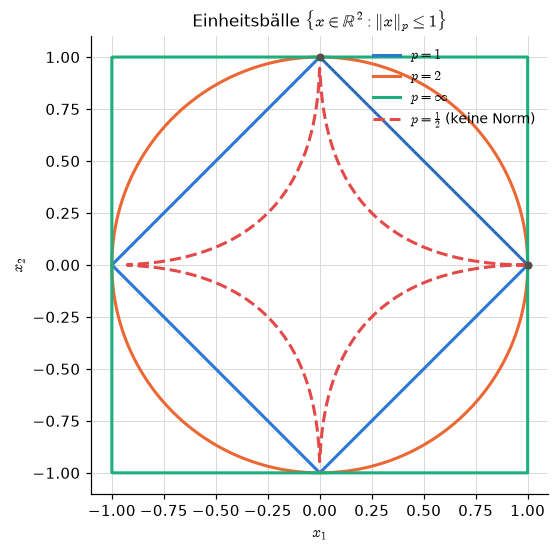

In [3]:
def unit_ball(p, n_points=2000):
    """Randkurve des p-Einheitsballs in R^2, in Polarkoordinaten abgetastet."""
    theta = np.linspace(0, 2 * np.pi, n_points)
    direction = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    radius = 1.0 / p_norm(direction, p)
    return radius * direction[:, 0], radius * direction[:, 1]


fig, ax = plt.subplots(figsize=(5.4, 5.4))
for p, label in [(1.0, r"$p=1$"), (2.0, r"$p=2$"), (np.inf, r"$p=\infty$")]:
    bx, by = unit_ball(p)
    ax.plot(bx, by, label=label)

bx, by = unit_ball(0.5)
ax.plot(bx, by, color=PALETTE[4], linestyle="--", label=r"$p=\frac{1}{2}$ (keine Norm)")

# Gegenbeispiel aus Satz 1.3: die Sehne zwischen e1 und e2 verlässt den Ball
ax.plot([1, 0], [0, 1], color="#52514e", linewidth=1.0, linestyle=":")
ax.scatter([1, 0], [0, 1], color="#52514e", s=18, zorder=5)

ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(r"Einheitsbälle $\{x \in \mathbb{R}^2 : \|x\|_p \leq 1\}$")
ax.legend(loc="upper right", fontsize=9)
plt.show()

**Abbildung 1.1** — Einheitsbälle der $p$-Norm. Für $p \ge 1$ sind sie konvex; die gepunktete
Sehne zwischen $e_1$ und $e_2$ liegt in jedem dieser Bälle. Für $p = \tfrac12$ ist der Rand nach
innen gekrümmt, die Sehne verlässt die Menge — genau die in Satz 1.3 nachgerechnete Verletzung
der Dreiecksungleichung.

> **Satz 1.4 (Normäquivalenz).** Auf $\mathbb{R}^n$ sind alle Normen äquivalent: zu Normen
> $\|\cdot\|_a, \|\cdot\|_b$ existieren Konstanten $0 < c \le C$ mit
> $c\,\|x\|_b \le \|x\|_a \le C\,\|x\|_b$ für alle $x$. Für die $p$-Normen gilt insbesondere
> $$\|x\|_\infty \;\le\; \|x\|_2 \;\le\; \|x\|_1 \;\le\; \sqrt{n}\,\|x\|_2 \;\le\; n\,\|x\|_\infty .$$

Die Äquivalenz bedeutet: Konvergenz, Stetigkeit und Kompaktheit hängen in endlicher Dimension
*nicht* von der Normwahl ab. Die Konstanten wachsen jedoch mit $n$ — und genau diese
$n$-Abhängigkeit ist der Grund, weshalb die Normwahl in hochdimensionalen Anwendungen praktisch
sehr wohl einen Unterschied macht (Abschnitt 5).

In [4]:
# Numerische Kontrolle der Ungleichungskette aus Satz 1.4
n, n_samples = 50, 20_000
X = rng.normal(size=(n_samples, n))
n_inf, n_2, n_1 = p_norm(X, np.inf), p_norm(X, 2.0), p_norm(X, 1.0)

checks = {
    "||x||_inf <= ||x||_2":       n_inf <= n_2 + 1e-12,
    "||x||_2   <= ||x||_1":       n_2 <= n_1 + 1e-12,
    "||x||_1   <= sqrt(n)||x||_2": n_1 <= np.sqrt(n) * n_2 + 1e-12,
}
for name, ok in checks.items():
    print(f"{name:<29} in allen {n_samples} Stichproben erfüllt: {bool(ok.all())}")

print(f"\nBeobachtete Verhältnisse bei n = {n} (Mittelwert +/- Standardabweichung):")
print(f"  ||x||_1 / ||x||_2   = {np.mean(n_1 / n_2):.3f} +/- {np.std(n_1 / n_2):.3f}"
      f"   (Schranke sqrt(n) = {np.sqrt(n):.3f})")
print(f"  ||x||_2 / ||x||_inf = {np.mean(n_2 / n_inf):.3f} +/- {np.std(n_2 / n_inf):.3f}"
      f"   (Schranke sqrt(n) = {np.sqrt(n):.3f})")

||x||_inf <= ||x||_2          in allen 20000 Stichproben erfüllt: True
||x||_2   <= ||x||_1          in allen 20000 Stichproben erfüllt: True
||x||_1   <= sqrt(n)||x||_2   in allen 20000 Stichproben erfüllt: True

Beobachtete Verhältnisse bei n = 50 (Mittelwert +/- Standardabweichung):
  ||x||_1 / ||x||_2   = 5.668 +/- 0.209   (Schranke sqrt(n) = 7.071)
  ||x||_2 / ||x||_inf = 2.849 +/- 0.372   (Schranke sqrt(n) = 7.071)


<a id="2"></a>
## 2 Metriken und die induzierte Distanz

> **Definition 2.1 (Metrik).** Sei $X$ eine Menge. Eine Abbildung
> $d : X \times X \to \mathbb{R}_{\ge 0}$ heißt *Metrik*, wenn für alle $x, y, z \in X$ gilt:
>
> | | Axiom | Bedeutung |
> |---|---|---|
> | (M1) | $d(x,y) = 0 \iff x = y$ | Identität der Ununterscheidbaren |
> | (M2) | $d(x,y) = d(y,x)$ | Symmetrie |
> | (M3) | $d(x,z) \le d(x,y) + d(y,z)$ | Dreiecksungleichung |

> **Satz 2.2.** Ist $(V, \|\cdot\|)$ ein normierter Raum, so ist $d(x,y) := \|x - y\|$ eine Metrik.
>
> *Beweis.* (M1) folgt aus (N1), da $\|x-y\| = 0 \iff x - y = 0$. (M2) folgt aus (N2) mit
> $\lambda = -1$: $\|x-y\| = \|-(y-x)\| = \|y-x\|$. Für (M3) schreibe $x - z = (x-y) + (y-z)$ und
> wende (N3) an. $\square$

Die Umkehrung gilt nicht: Nicht jede Metrik stammt von einer Norm (eine von einer Norm induzierte
Metrik ist translationsinvariant und homogen, eine allgemeine Metrik nicht). Für die Praxis
wichtiger ist die folgende Konsequenz: Verletzt eine Ähnlichkeitsfunktion die Dreiecksungleichung,
so verlieren metrische Indexstrukturen (Ball-Tree, Vantage-Point-Tree) ihre Korrektheitsgarantie —
sie können echte nächste Nachbarn übersehen.

Die folgende Funktion prüft die Axiome numerisch anhand von Zufallsstichproben. Sie kann ein Axiom
**falsifizieren**, aber niemals beweisen — ein bestandener Test ist ein Indiz, kein Beleg.

In [5]:
def check_metric_axioms(d, dim=4, n_trials=5_000, rng=rng):
    """Falsifiziert die Metrikaxiome (M1)-(M3) durch Zufallsstichproben.

    Rückgabe: dict mit dem jeweils groessten beobachteten Verstoss
    (0.0 = in dieser Stichprobe kein Gegenbeispiel gefunden)."""
    A = rng.normal(size=(n_trials, dim))
    B = rng.normal(size=(n_trials, dim))
    C = rng.normal(size=(n_trials, dim))

    d_ab = np.array([d(a, b) for a, b in zip(A, B)])
    d_ba = np.array([d(b, a) for a, b in zip(A, B)])
    d_bc = np.array([d(b, c) for b, c in zip(B, C)])
    d_ac = np.array([d(a, c) for a, c in zip(A, C)])
    d_aa = np.array([d(a, a) for a in A])

    return {
        "(M1) d(a,a) = 0":    float(np.max(np.abs(d_aa))),
        "(M1) d(a,b) >= 0":   float(max(0.0, -np.min(d_ab))),
        "(M2) Symmetrie":     float(np.max(np.abs(d_ab - d_ba))),
        "(M3) Dreiecksungl.": float(max(0.0, np.max(d_ac - (d_ab + d_bc)))),
    }


def euclidean(a, b):
    return float(np.linalg.norm(a - b, ord=2))


def manhattan(a, b):
    return float(np.linalg.norm(a - b, ord=1))


def chebyshev(a, b):
    return float(np.linalg.norm(a - b, ord=np.inf))


# Toleranz gegenüber Rundungsfehlern: Verstoesse unterhalb TOL sind numerisches
# Rauschen der Gleitkommaarithmetik, keine echten Gegenbeispiele.
TOL = 1e-6

for name, d in [("euklidisch (L2)", euclidean), ("Manhattan (L1)", manhattan),
                ("Tschebyschow (Linf)", chebyshev)]:
    worst = max(check_metric_axioms(d).values())
    verdict = "kein Gegenbeispiel gefunden" if worst < TOL else "VERLETZT"
    print(f"{name:<22} groesster Verstoss: {worst:.2e}  ->  {verdict}")

euklidisch (L2)        groesster Verstoss: 0.00e+00  ->  kein Gegenbeispiel gefunden
Manhattan (L1)         groesster Verstoss: 1.78e-15  ->  kein Gegenbeispiel gefunden


Tschebyschow (Linf)    groesster Verstoss: 8.88e-16  ->  kein Gegenbeispiel gefunden


<a id="3"></a>
## 3 Skalarprodukt, Cauchy–Schwarz und Winkel

> **Definition 3.1 (Standardskalarprodukt).** Für $a, b \in \mathbb{R}^n$ sei
> $\langle a, b\rangle = a^\top b = \sum_{i=1}^n a_i b_i$. Es gilt
> $\|a\|_2 = \sqrt{\langle a,a\rangle}$; die euklidische Norm ist also die vom Skalarprodukt
> *induzierte* Norm.

> **Satz 3.2 (Cauchy–Schwarz).** Für alle $a, b \in \mathbb{R}^n$ gilt
> $$\lvert \langle a, b \rangle \rvert \;\le\; \|a\|_2\,\|b\|_2,$$
> mit Gleichheit genau dann, wenn $a$ und $b$ linear abhängig sind.
>
> *Beweis.* Für $b = 0$ sind beide Seiten null. Sei also $b \ne 0$ und
> $$q(t) \;=\; \|a + t b\|_2^2 \;=\; \|a\|^2 + 2t\,\langle a,b\rangle + t^2 \|b\|^2 \;\ge\; 0
> \qquad \text{für alle } t \in \mathbb{R}.$$
> $q$ ist ein quadratisches Polynom in $t$ mit positivem Leitkoeffizienten, das nirgends negativ
> wird. Seine Diskriminante ist daher $\le 0$:
> $$4\langle a,b\rangle^2 - 4\|a\|^2\|b\|^2 \le 0 \iff \langle a,b\rangle^2 \le \|a\|^2\|b\|^2 .$$
> Gleichheit tritt genau dann ein, wenn $q$ eine doppelte Nullstelle $t^\ast$ besitzt, also
> $\|a + t^\ast b\| = 0$ und damit $a = -t^\ast b$. $\square$

> **Definition 3.3 (Winkel und Kosinus-Ähnlichkeit).** Für $a, b \ne 0$ ist
> $$\cos \angle(a,b) \;=\; \frac{\langle a,b\rangle}{\|a\|_2\,\|b\|_2}
> \;=:\; \operatorname{sim}_{\cos}(a,b) \;\in\; [-1, 1],$$
> wobei die Wohldefiniertheit — also $\lvert\cos\angle(a,b)\rvert \le 1$ — unmittelbar aus
> Satz 3.2 folgt. Der Winkel ist
> $\angle(a,b) = \arccos \operatorname{sim}_{\cos}(a,b) \in [0, \pi]$.

Die Kosinus-Ähnlichkeit ist **skaleninvariant**:
$\operatorname{sim}_{\cos}(\lambda a, b) = \operatorname{sim}_{\cos}(a,b)$ für $\lambda > 0$.
Genau deshalb ist sie im Text-Retrieval Standard — die Länge eines Dokumentvektors trägt dort
meist keine semantische Information, seine Richtung schon.

In [6]:
def cosine_similarity(a, b):
    """Kosinus-Ähnlichkeit nach Definition 3.3.

    Bewusst ohne Epsilon-Glättung im Nenner: für den Nullvektor ist der Winkel
    nicht definiert: ein stillschweigend zurueckgegebener Wert wuerde einen
    Datenfehler verdecken, statt ihn zu melden."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0.0 or nb == 0.0:
        raise ValueError("Kosinus-Ähnlichkeit ist für den Nullvektor nicht definiert.")
    return float(np.dot(a, b) / (na * nb))


def cosine_distance(a, b):
    return 1.0 - cosine_similarity(a, b)


def angular_distance(a, b):
    """Normierte Winkeldistanz arccos(sim)/pi in [0, 1] - im Gegensatz zur
    Kosinus-Distanz eine echte Metrik (Bemerkung 4.2)."""
    return float(np.arccos(np.clip(cosine_similarity(a, b), -1.0, 1.0)) / np.pi)


e1, e2 = np.array([1.0, 0.0]), np.array([0.0, 1.0])
print(f"identisch:       sim = {cosine_similarity(e1, e1):+.4f}")
print(f"orthogonal:      sim = {cosine_similarity(e1, e2):+.4f}")
print(f"antiparallel:    sim = {cosine_similarity(e1, -e1):+.4f}")
print(f"skaleninvariant: sim(3a,b) - sim(a,b) = "
      f"{cosine_similarity(3 * e1, e1 + e2) - cosine_similarity(e1, e1 + e2):.2e}")

# Cauchy-Schwarz empirisch: der Quotient darf 1 niemals ueberschreiten
A, B = rng.normal(size=(100_000, 8)), rng.normal(size=(100_000, 8))
ratio = np.abs(np.sum(A * B, axis=1)) / (np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1))
print(f"\nCauchy-Schwarz, 100000 Zufallspaare: max |<a,b>|/(||a|| ||b||) = {ratio.max():.10f}")

identisch:       sim = +1.0000
orthogonal:      sim = +0.0000
antiparallel:    sim = -1.0000
skaleninvariant: sim(3a,b) - sim(a,b) = 0.00e+00



Cauchy-Schwarz, 100000 Zufallspaare: max |<a,b>|/(||a|| ||b||) = 0.9873915040


<a id="4"></a>
## 4 Die Kosinus-Distanz ist keine Metrik

In Bibliotheken und Vektordatenbanken wird $d_{\cos}(a,b) = 1 - \operatorname{sim}_{\cos}(a,b)$
routinemäßig als „Distanz“ geführt. Das ist begrifflich falsch:

> **Satz 4.1.** $d_{\cos}$ verletzt die Dreiecksungleichung (M3).
>
> *Beweis (Gegenbeispiel).* Sei $a = (1,0)^\top$, $b = (1,1)^\top$, $c = (0,1)^\top$. Dann ist
> $$d_{\cos}(a,b) = d_{\cos}(b,c) = 1 - \tfrac{1}{\sqrt{2}} \approx 0{,}2929,
> \qquad d_{\cos}(a,c) = 1 - 0 = 1 .$$
> Also $d_{\cos}(a,c) = 1 > 0{,}5858 \approx d_{\cos}(a,b) + d_{\cos}(b,c)$. $\square$

Anschaulich: $d_{\cos}$ misst $1 - \cos\theta$ statt $\theta$. Da $1-\cos$ für kleine Winkel
quadratisch wächst ($1 - \cos\theta \approx \theta^2/2$), werden zwei kleine Winkel gegenüber
ihrer Summe systematisch unterbewertet.

> **Bemerkung 4.2 (Reparatur).** Die *Winkeldistanz*
> $d_\angle(a,b) = \tfrac{1}{\pi}\arccos\operatorname{sim}_{\cos}(a,b)$ ist auf der Menge der
> Strahlen $\{\lambda a : \lambda > 0\}$ eine Metrik — sie ist die Geodätendistanz auf der
> Einheitssphäre und erbt (M3) von deren Riemannscher Struktur. Ebenso ist
> $\sqrt{2\,d_{\cos}(a,b)} = \big\|\tfrac{a}{\|a\|} - \tfrac{b}{\|b\|}\big\|_2$ eine Metrik,
> nämlich die euklidische Distanz der normierten Vektoren. Wer metrische Indexstrukturen
> einsetzen will, verwendet eine dieser beiden Größen.

Beachten Sie, dass $d_{\cos}$ zusätzlich (M1) verletzt: $d_{\cos}(a, 2a) = 0$ für $a \ne 0$,
obwohl $a \ne 2a$. Auf dem Quotientenraum der Strahlen ist das behoben, die Dreiecksungleichung
dagegen nicht.

In [7]:
# Satz 4.1: explizites Gegenbeispiel
a, b, c = np.array([1.0, 0.0]), np.array([1.0, 1.0]), np.array([0.0, 1.0])

print("Kosinus-Distanz:")
print(f"  d(a,b) = {cosine_distance(a, b):.4f}")
print(f"  d(b,c) = {cosine_distance(b, c):.4f}")
print(f"  d(a,c) = {cosine_distance(a, c):.4f}   >  d(a,b)+d(b,c) = "
      f"{cosine_distance(a, b) + cosine_distance(b, c):.4f}   -> (M3) verletzt")

print("\nWinkeldistanz (Bemerkung 4.2):")
print(f"  d(a,b) = {angular_distance(a, b):.4f}")
print(f"  d(b,c) = {angular_distance(b, c):.4f}")
print(f"  d(a,c) = {angular_distance(a, c):.4f}  <= d(a,b)+d(b,c) = "
      f"{angular_distance(a, b) + angular_distance(b, c):.4f}   -> (M3) erfüllt")

print(f"\n(M1) verletzt: d_cos(a, 2a) = {cosine_distance(a, 2 * a):.4f}, obwohl a != 2a")

Kosinus-Distanz:
  d(a,b) = 0.2929
  d(b,c) = 0.2929
  d(a,c) = 1.0000   >  d(a,b)+d(b,c) = 0.5858   -> (M3) verletzt

Winkeldistanz (Bemerkung 4.2):
  d(a,b) = 0.2500
  d(b,c) = 0.2500
  d(a,c) = 0.5000  <= d(a,b)+d(b,c) = 0.5000   -> (M3) erfüllt

(M1) verletzt: d_cos(a, 2a) = 0.0000, obwohl a != 2a


In [8]:
# Systematische Stichprobenpruefung beider Kandidaten
for name, d in [("Kosinus-Distanz", cosine_distance), ("Winkeldistanz", angular_distance)]:
    print(f"\n{name}")
    for axiom, violation in check_metric_axioms(d, dim=3).items():
        verdict = "ok      " if violation < TOL else "VERLETZT"
        print(f"  {axiom:<22} {verdict}  groesster Verstoss: {violation:.2e}")


Kosinus-Distanz


  (M1) d(a,a) = 0        ok        groesster Verstoss: 2.22e-16
  (M1) d(a,b) >= 0       ok        groesster Verstoss: 0.00e+00
  (M2) Symmetrie         ok        groesster Verstoss: 0.00e+00
  (M3) Dreiecksungl.     VERLETZT  groesster Verstoss: 4.99e-01

Winkeldistanz


  (M1) d(a,a) = 0        ok        groesster Verstoss: 6.71e-09
  (M1) d(a,b) >= 0       ok        groesster Verstoss: 0.00e+00
  (M2) Symmetrie         ok        groesster Verstoss: 0.00e+00
  (M3) Dreiecksungl.     ok        groesster Verstoss: 0.00e+00


Die Stichprobenprüfung reproduziert das analytische Ergebnis: Für $d_{\cos}$ findet der Test
Gegenbeispiele zu (M3). Die Verletzung ist also kein Artefakt des konstruierten Beispiels, sondern
tritt bei zufälligen Tripeln regelmäßig auf. Für $d_\angle$ findet er keine — im Einklang mit
Bemerkung 4.2. Zwei Lesehinweise zur Tabelle: Erstens ist die Toleranz `TOL` notwendig, weil
$\arccos$ nahe $\pm 1$ Stellen verliert — für $\cos\theta = 1-\varepsilon$ ist
$\arccos(1-\varepsilon) \approx \sqrt{2\varepsilon}$, die Kondition ist dort also schlecht, und
$d_\angle(a,a)$ wird nur bis auf $\mathcal{O}(\sqrt{\varepsilon_{\text{mach}}}) \approx 10^{-8}$
genau null. Zweitens erfüllen beide Kandidaten die Rückrichtung von (M1) auf $\mathbb{R}^n$ nicht:
Sie sind Metriken auf dem Quotientenraum der Strahlen, nicht auf $\mathbb{R}^n$ selbst.

<a id="5"></a>
## 5 Distanzkonzentration in hohen Dimensionen

Distanzbasierte Verfahren setzen stillschweigend voraus, dass „nah“ und „fern“ unterscheidbar
sind. Beyer et al. (1999) haben gezeigt, dass diese Voraussetzung in hohen Dimensionen unter
milden Annahmen zusammenbricht. Als Kennzahl dient der *relative Kontrast* einer Anfrage $q$
bezüglich einer Punktmenge $\{x^{(1)},\dots,x^{(m)}\}$:
$$\rho_d \;=\; \frac{\max_i d(q, x^{(i)}) - \min_i d(q, x^{(i)})}{\min_i d(q, x^{(i)})} .$$

> **Satz 5.1 (Beyer et al. 1999, vereinfachte Fassung).** Sind die Komponenten unabhängig und
> identisch verteilt mit endlicher Varianz, so gilt für die euklidische Distanz
> $\rho_d \xrightarrow{\;P\;} 0$ für $d \to \infty$.
>
> *Beweisskizze.* Für $q = 0$ ist $\|x\|_2^2 = \sum_{j=1}^d x_j^2$ eine Summe von $d$ i.i.d.
> Termen. Nach dem Gesetz der großen Zahlen ist $\mathbb{E}\|x\|_2 = \Theta(\sqrt{d})$, während
> die Standardabweichung nach dem zentralen Grenzwertsatz nur $\Theta(1)$ beträgt. Der relative
> Streubereich verhält sich also wie $\Theta(1)/\Theta(\sqrt d) \to 0$. $\square$

Die Konsequenz ist unbequem: Der nächste Nachbar ist in hoher Dimension kaum noch näher als der
fernste, und kleine Störungen der Daten ändern die Rangfolge. Wir messen den Effekt für
$L_1$, $L_2$ und $L_\infty$.

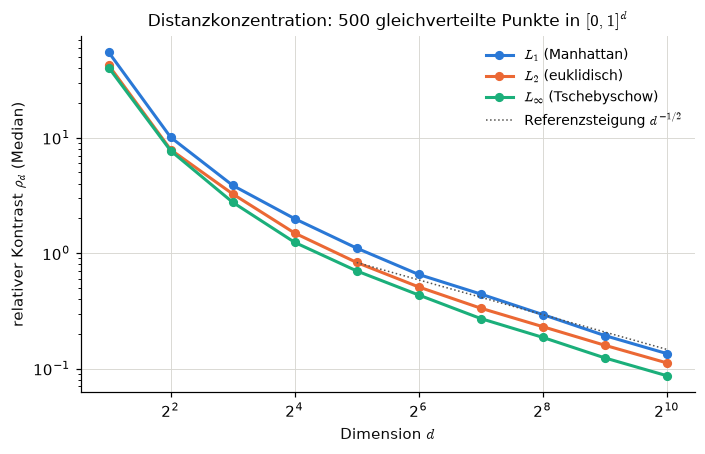

     d |       L1 |       L2 |     Linf
----------------------------------------
     2 |   54.964 |   42.421 |   40.497
     4 |   10.071 |    7.871 |    7.703
     8 |    3.862 |    3.258 |    2.758
    16 |    1.987 |    1.492 |    1.240
    32 |    1.105 |    0.830 |    0.701
    64 |    0.654 |    0.510 |    0.434
   128 |    0.443 |    0.334 |    0.271
   256 |    0.294 |    0.231 |    0.186
   512 |    0.193 |    0.159 |    0.124
  1024 |    0.135 |    0.112 |    0.087

Geschätzte Rate rho_d ~ d^alpha im Bereich d >= 32:
  $L_1$ (Manhattan)            alpha = -0.601
  $L_2$ (euklidisch)           alpha = -0.571
  $L_\infty$ (Tschebyschow)    alpha = -0.601


In [9]:
def relative_contrast(dim, n_points=500, p=2.0, n_queries=60, rng=rng):
    """Relativer Kontrast (max-min)/min fuer gleichverteilte Punkte in [0,1]^dim.

    Aggregiert wird der Median ueber die Anfragen: der Mittelwert ist wegen des
    Nenners min_i d(q, x_i) schwerlastig und in kleinen Dimensionen instabil."""
    values = []
    for _ in range(n_queries):
        X = rng.random((n_points, dim))
        q = rng.random(dim)
        dists = p_norm(X - q, p)
        values.append((dists.max() - dists.min()) / dists.min())
    return float(np.median(values))


dims = np.array([2, 4, 8, 16, 32, 64, 128, 256, 512, 1024])
contrast = {
    r"$L_1$ (Manhattan)": np.array([relative_contrast(d, p=1.0) for d in dims]),
    r"$L_2$ (euklidisch)": np.array([relative_contrast(d, p=2.0) for d in dims]),
    r"$L_\infty$ (Tschebyschow)": np.array([relative_contrast(d, p=np.inf) for d in dims]),
}

# Empirische Rate: Steigung im Log-Log-Diagramm im asymptotischen Bereich d >= 32
mask = dims >= 32
rates = {label: np.polyfit(np.log(dims[mask]), np.log(v[mask]), 1)[0]
         for label, v in contrast.items()}

fig, ax = plt.subplots()
for label, values in contrast.items():
    ax.plot(dims, values, marker="o", markersize=5, label=label)

ref = contrast[r"$L_2$ (euklidisch)"][mask][0] * (dims[mask] / dims[mask][0]) ** -0.5
ax.plot(dims[mask], ref, color="#52514e", linewidth=1.0, linestyle=":",
        label=r"Referenzsteigung $d^{-1/2}$")

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Dimension $d$")
ax.set_ylabel(r"relativer Kontrast $\rho_d$ (Median)")
ax.set_title(r"Distanzkonzentration: 500 gleichverteilte Punkte in $[0,1]^d$")
ax.legend(fontsize=9)
plt.show()

print(f"{'d':>6} | {'L1':>8} | {'L2':>8} | {'Linf':>8}")
print("-" * 40)
for i, dim in enumerate(dims):
    row = [v[i] for v in contrast.values()]
    print(f"{dim:>6} | {row[0]:>8.3f} | {row[1]:>8.3f} | {row[2]:>8.3f}")

print("\nGeschätzte Rate rho_d ~ d^alpha im Bereich d >= 32:")
for label, alpha in rates.items():
    print(f"  {label:<28} alpha = {alpha:+.3f}")

**Abbildung 1.2** — Relativer Kontrast über der Dimension (doppelt logarithmisch). Alle drei
Normen verlieren Kontrast. Die gepunktete Referenzlinie zeigt die in Satz 5.1 hergeleitete Rate
$d^{-1/2}$; die gemessenen Kurven fallen etwas steiler ab. Das ist kein Widerspruch: Satz 5.1
beschreibt das Verhältnis von Streuung zu Erwartungswert *einer* Distanz, während $\rho_d$ hier
über die **Extremwerte** von $m = 500$ Distanzen gebildet wird. Deren Spannweite schrumpft
zusätzlich, weil die Verteilung der Distanzen mit wachsendem $d$ nicht nur relativ schmaler,
sondern auch symmetrischer wird. Für festes $m$ und $d \to \infty$ bleibt der qualitative
Befund — $\rho_d \to 0$ — unverändert.

**Interpretation.** Bei $d = 2$ ist der fernste Punkt um ein Vielfaches weiter entfernt als der
nächste; bei $d = 1024$ unterscheiden sich beide nur noch um wenige Prozent. Der Rangvergleich,
auf dem $k$-NN beruht, wird dadurch zunehmend anfällig gegen Rauschen. Bemerkenswert ist die
Ordnung der Kurven: $L_1$ hält den Kontrast am längsten, $L_\infty$ am schlechtesten — ein
Argument für kleine $p$ in hochdimensionalen Räumen (Aggarwal et al. 2001). Die praktisch
wirksamste Gegenmaßnahme ist allerdings nicht die Normwahl, sondern **Dimensionsreduktion**:
Reale Daten liegen meist nahe an einer niedrigdimensionalen Mannigfaltigkeit, deren intrinsische
Dimension weit unter $d$ liegt.

<a id="6"></a>
## 6 Merkmalsskalierung

Die euklidische Distanz gewichtet alle Koordinaten gleich. Werden Merkmale in unterschiedlichen
Einheiten gemessen — Alter in Jahren, Einkommen in Euro —, so dominiert das Merkmal mit der
größten Streuung die Distanz nahezu vollständig. Zwei Standardtransformationen:

> **Definition 6.1.** Für eine Stichprobe $x^{(1)},\dots,x^{(m)} \in \mathbb{R}$ sei
> $$\text{Min-Max:}\quad \tilde x = \frac{x - \min_i x^{(i)}}{\max_i x^{(i)} - \min_i x^{(i)}} \in [0,1],
> \qquad
> \text{$z$-Standardisierung:}\quad \hat x = \frac{x - \bar x}{s},$$
> mit empirischem Mittel $\bar x$ und empirischer Standardabweichung $s > 0$.

Die $z$-Standardisierung erzeugt Mittelwert $0$ und Standardabweichung $1$; sie ist gegenüber
Ausreißern robuster als Min-Max, das den gesamten Wertebereich an zwei Extremwerte koppelt.
Beide sind *affine* Transformationen pro Koordinate und ändern die Rangfolge innerhalb einer
Koordinate nicht — wohl aber die **Rangfolge der Nachbarn**, wie das folgende Experiment zeigt.

In [10]:
def standardize(X, mu=None, sigma=None):
    """z-Standardisierung spaltenweise. mu und sigma werden auf den Trainingsdaten
    geschaetzt und danach unveraendert weiterverwendet (siehe Hinweis zu Leakage)."""
    X = np.atleast_2d(np.asarray(X, dtype=float))
    if mu is None or sigma is None:
        mu, sigma = X.mean(axis=0), X.std(axis=0)
    safe = np.where(sigma > 0, sigma, 1.0)
    return np.where(sigma > 0, (X - mu) / safe, 0.0), mu, sigma


def minmax(X):
    """Min-Max-Normalisierung spaltenweise auf [0, 1]."""
    X = np.atleast_2d(np.asarray(X, dtype=float))
    lo, hi = X.min(axis=0), X.max(axis=0)
    span = np.where(hi > lo, hi - lo, 1.0)
    return np.where(hi > lo, (X - lo) / span, 0.0)


# Zwei Merkmale mit gleicher Struktur, aber Merkmal 2 in 100-fach groesserer Einheit
m, k = 300, 10
X = np.column_stack([rng.normal(0.0, 1.0, size=m), rng.normal(0.0, 100.0, size=m)])
q = np.array([0.0, 0.0])

Z, mu, sigma = standardize(X)
q_z = (q - mu) / sigma

nn_raw = np.argsort(p_norm(X - q, 2.0))[:k]
nn_std = np.argsort(p_norm(Z - q_z, 2.0))[:k]

anteil = np.mean((X[:, 1] - q[1]) ** 2 / np.sum((X - q) ** 2, axis=1))
print(f"Standardabweichung je Merkmal: {X.std(axis=0)}")
print(f"Wertebereich nach Min-Max je Merkmal: "
      f"[{minmax(X).min(axis=0)[0]:.1f}, {minmax(X).max(axis=0)[0]:.1f}] bzw. "
      f"[{minmax(X).min(axis=0)[1]:.1f}, {minmax(X).max(axis=0)[1]:.1f}]")
print(f"Mittlerer Anteil von Merkmal 2 an der quadrierten Distanz (ungeskaliert): {anteil:.4f}")
print(f"\n{k} nächste Nachbarn ohne Skalierung:          {np.sort(nn_raw)}")
print(f"{k} nächste Nachbarn nach z-Standardisierung: {np.sort(nn_std)}")
print(f"Übereinstimmung: {len(set(nn_raw) & set(nn_std))} von {k}")

Standardabweichung je Merkmal: [ 0.9681 96.6417]
Wertebereich nach Min-Max je Merkmal: [0.0, 1.0] bzw. [0.0, 1.0]
Mittlerer Anteil von Merkmal 2 an der quadrierten Distanz (ungeskaliert): 0.9910

10 nächste Nachbarn ohne Skalierung:          [  6  10  50  75 107 130 147 186 220 242]
10 nächste Nachbarn nach z-Standardisierung: [ 79  80  85  93 220 254 257 261 292 296]
Übereinstimmung: 1 von 10


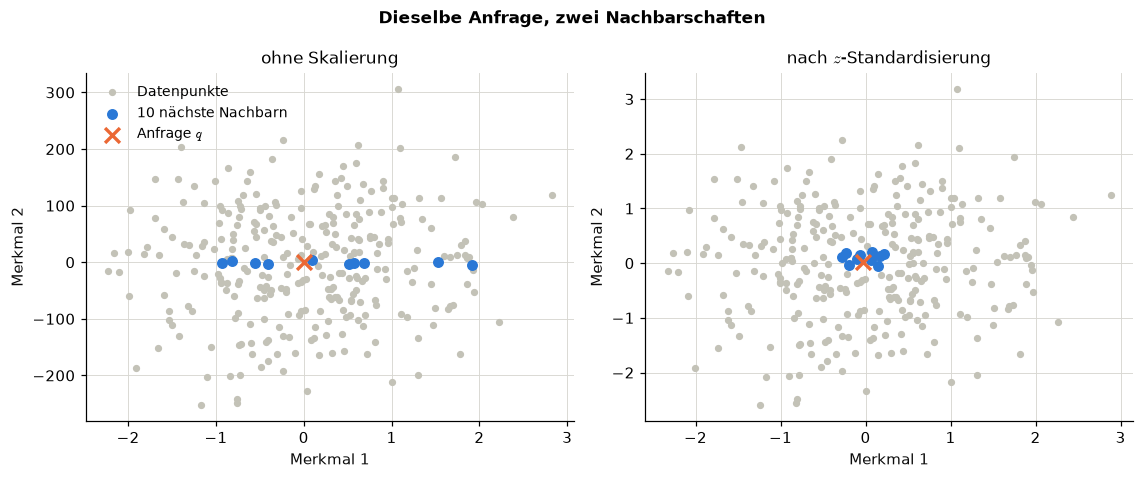

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))

for ax, data, point, idx, title in [
    (axes[0], X, q, nn_raw, "ohne Skalierung"),
    (axes[1], Z, q_z, nn_std, "nach $z$-Standardisierung"),
]:
    ax.scatter(data[:, 0], data[:, 1], s=14, color="#c3c2b7", label="Datenpunkte")
    ax.scatter(data[idx, 0], data[idx, 1], s=38, color=PALETTE[0],
               label=f"{k} nächste Nachbarn")
    ax.scatter(*point, marker="x", s=95, color=PALETTE[1], linewidths=2.2,
               label="Anfrage $q$", zorder=5)
    ax.set_xlabel("Merkmal 1")
    ax.set_ylabel("Merkmal 2")
    ax.set_title(title)

axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("Dieselbe Anfrage, zwei Nachbarschaften", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.show()

**Abbildung 1.3** — Ohne Skalierung (links) liegen die ausgewählten Nachbarn in einem schmalen
horizontalen Band: Merkmal 2 dominiert die Distanz, Merkmal 1 ist praktisch irrelevant. Nach der
$z$-Standardisierung (rechts) ist die Nachbarschaft isotrop. Die beiden Nachbarmengen
überschneiden sich nur teilweise — dieselbe Anfrage, dasselbe Verfahren, unterschiedliches
Ergebnis.

**Konsequenz für die Praxis.** Die Skalierungsparameter $\mu, \sigma$ (bzw. $\min, \max$) sind
Modellparameter: Sie werden **auf den Trainingsdaten geschätzt** und danach unverändert auf
Validierungs- und Testdaten angewandt. Wird die Skalierung auf dem Gesamtdatensatz berechnet,
fließt Information aus dem Testteil in das Training ein (*data leakage*), und die geschätzte
Generalisierungsleistung wird optimistisch verzerrt.

<a id="7"></a>
## 7 Übungsaufgaben

**Aufgabe 1.1 (Normaxiome).** Zeigen Sie, dass $\|x\|_A := \sqrt{x^\top A x}$ für eine symmetrisch
positiv definite Matrix $A \in \mathbb{R}^{n\times n}$ eine Norm ist. Welche geometrische Gestalt
hat der zugehörige Einheitsball? Implementieren Sie $\|\cdot\|_A$ und zeichnen Sie den Einheitsball
für $A = \left(\begin{smallmatrix} 2 & 1 \\ 1 & 1\end{smallmatrix}\right)$ analog zu Abbildung 1.1.

**Aufgabe 1.2 (Mahalanobis-Distanz).** Die Distanz $d_\Sigma(x,y) = \|x-y\|_{\Sigma^{-1}}$ mit der
Kovarianzmatrix $\Sigma$ heißt Mahalanobis-Distanz. Begründen Sie, weshalb sie für korrelierte
Merkmale der euklidischen Distanz vorzuziehen ist, und zeigen Sie, dass sie für $\Sigma = I$ in
diese übergeht. Prüfen Sie die Metrikaxiome mit `check_metric_axioms`.

**Aufgabe 1.3 (Gegenbeispiel konstruieren).** Zeigen Sie, dass die *quadrierte* euklidische
Distanz $d(x,y) = \|x-y\|_2^2$ keine Metrik ist, indem Sie ein Gegenbeispiel in $\mathbb{R}$
angeben. Warum wird sie in der Praxis dennoch häufig verwendet (Stichwort: $k$-Means)?

**Aufgabe 1.4 (Intrinsische Dimension).** Wiederholen Sie das Experiment aus Abschnitt 5 mit Daten,
die auf einer zweidimensionalen Ebene innerhalb des $\mathbb{R}^d$ liegen (etwa $x = Uz$ mit
$z \in \mathbb{R}^2$ und festem $U \in \mathbb{R}^{d\times 2}$). Was beobachten Sie, und wie passt
das zur Bemerkung über die intrinsische Dimension?

**Aufgabe 1.5 (Skalierung und Leakage).** Konstruieren Sie ein Beispiel, in dem eine auf dem
Gesamtdatensatz berechnete $z$-Standardisierung die Testgenauigkeit eines $1$-NN-Klassifikators
messbar überschätzt.

---

## Literatur

- Aggarwal, C. C., Hinneburg, A., Keim, D. A. (2001). *On the Surprising Behavior of Distance
  Metrics in High Dimensional Space.* ICDT 2001, LNCS 1973, S. 420–434.
- Beyer, K., Goldstein, J., Ramakrishnan, R., Shaft, U. (1999). *When Is „Nearest Neighbor“
  Meaningful?* ICDT 1999, LNCS 1540, S. 217–235.
- Deisenroth, M. P., Faisal, A. A., Ong, C. S. (2020). *Mathematics for Machine Learning.*
  Cambridge University Press, Kapitel 3.
- Königsberger, K. (2004). *Analysis 1.* 6. Auflage, Springer, Kapitel 1.
- Strang, G. (2016). *Introduction to Linear Algebra.* 5. Auflage, Wellesley-Cambridge Press.